# Problem Statement

## Business Context

As organizations grow and scale, they are often inundated with large volumes of data, reports, and documents that contain critical information for decision-making. In real-world business settings, such as venture capital firms like Andreesen Horowitz, business analysts are required to sift through large datasets, research papers, or reports to extract relevant information that impacts strategic decisions.

For instance, consider that you've just joined Andreesen Horowitz, a renowned venture capital firm, and you are tasked with analyzing a dense report like the Harvard Business Review's **"How Apple is Organized for Innovation."** Going through the report manually can be extremely time-consuming as the size and complexity of these report increases. However, by using **Semantic Search** and **Retrieval-Augmented Generation (RAG)** models, you can significantly streamline this process.

Imagine having the capability to directly ask questions like, “How does Apple structure its teams for innovation?” and get immediate, relevant answers drawn from the report. This ability to extract and organize specific insights quickly and accurately enables you to focus on higher-level analysis and decision-making, rather than being bogged down by information retrieval.

## Objective

The goal is to develop a RAG application that helps business analysts efficiently extract key insights from extensive reports, such as “How Apple is Organized for Innovation.”

Specifically, the system aims to:

- Answer user queries by retrieving relevant content directly from lengthy documents.

- Support natural-language interaction without requiring a full manual read-through.

- Act as an intelligent assistant that streamlines the report analysis process.

Through this solution, analysts can save time, improve productivity, and make faster, more informed strategic decisions

## Data Description

**How Apple is Organized for Innovation** - An article of 11 pages in pdf format

## Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              langchain-text-splitters \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30 \
              openai 

In [6]:
import sys
!{sys.executable} -m pip install datasets
!"{sys.executable}" -m pip install pymupdf


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 39.8 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

## Restarting Google Colab -- Roy

I found this method on copilot.com, for restarting the runtime.  To paraphrase the result it generated for me, this method can be used to restart the python kernel after python packages are installed.

In [ ]:
def restartKernel():
    from IPython import get_ipython

    ipython = get_ipython()

    if ipython is None:
        raise RuntimeError("IPython not running inside Jupyter")

    ipython.kernel.do_shutdown(restart=True)

restartKernel()

: 

In [1]:
# Import core libraries
import os                                                                       # Interact with the operating system (e.g., set environment variables)
import json                                                                     # Read/write JSON data

# Import libraries for working with PDFs and OpenAI
                            # Load and extract text from PDF files
from openai import OpenAI                                                       # Access OpenAI's models and services
from langchain_community.document_loaders import PyMuPDFLoader
# Import libraries for processing dataframes and text
import tiktoken                                                                 # Tokenizer used for counting and splitting text for models
import pandas as pd                                                             # Load, manipulate, and analyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain_text_splitters import RecursiveCharacterTextSplitter             # Break text into overlapping chunks for processing
from langchain_openai import OpenAIEmbeddings                                   # Create vector embeddings using OpenAI's models  # type: ignore
from langchain_community.vectorstores import Chroma                             # Store and search vector embeddings using Chroma DB  # type: ignore

from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI        

/opt/homebrew/Caskroom/miniconda/base/envs/mlxrag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Question Answering using LLM

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

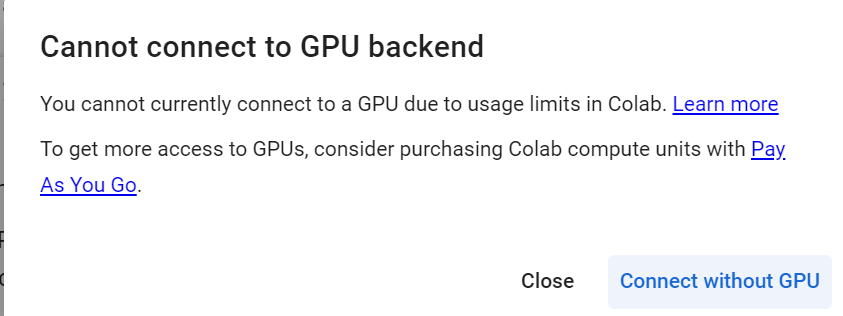

#### Downloading and Loading the model

# == == == == == == == == == == == -Roy
## Below is the method to connect and chat with Qwen3.6 and Qwen3-Embedding modules

Download the [mlx repo: https://github.com/kibotu/mlx-llm-server-mac-m-series](https://github.com/kibotu/mlx-llm-server-mac-m-series), to serve the LLM model.  In addition to connecting to and serving an LLM, it provides embedding services through the openAI python interface.

The LLM model chosen for this project is: [https://huggingface.co/mlx-community/Qwen3.6-35B-A3B-4bit](https://huggingface.co/mlx-community/Qwen3.6-35B-A3B-4bit), which has been converted to be used on Apple M-series chips and is based on the [https://huggingface.co/Qwen/Qwen3.6-35B-A3B](https://huggingface.co/Qwen/Qwen3.6-35B-A3B) LLM.  The reasoning for this choice is due to the hardware available on a local machine I have access to.

The Embedding model chosen for this project is: [https://huggingface.co/mlx-community/Qwen3-Embedding-4B-mxfp8](https://huggingface.co/mlx-community/Qwen3-Embedding-4B-mxfp8), which has been converted to Apple M-series chips and is based on the [https://huggingface.co/Qwen/Qwen3-Embedding-4B](https://huggingface.co/Qwen/Qwen3-Embedding-4B). I chose this model due to the above LLM choice.

To provide the services locally for a Jupyter notebook to connect to, run the following in a terminal to start the mlx service serving the qwen model, in the root directory of the repo above:

```
git clone https://github.com/kibotu/mlx-llm-server-mac-m-series
cd mlx-llm-server-mac-m-series
PORT=8898 MODEL=mlx-community/Qwen3.6-35B-A3B-4bit ./run.sh &
PORT=8899 MODEL=mlx-community/Qwen3-Embedding-4B-mxfp8 ./run.sh &
```

# -- -- -- -- -- -- -- --

Using the below method to load

In [2]:
from openai import OpenAI
import time

client = OpenAI(
    base_url="http://localhost:8899/v1",
    api_key="none"
)

MODEL_NAME="mlx-community/Qwen3.6-35B-A3B-4bit"
MODEL_PATH="mlx-community/Qwen3.6-35B-A3B-4bit"

def askQuestionForResponse(my_question=""):
    time.sleep(2)

    resp = client.chat.completions.create(
        model=MODEL_PATH,
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant."
            },
            {
                "role": "user",
                "content": my_question
            }
        ],
        stream=True
    )

    full_text = ""

    #####
    # Use the streaming method to get all of the output from the resp (response) stream
    for bundle in resp:

        try:
            choice = bundle.choices[0]

            if hasattr(choice.delta, "content"):
                chunk = choice.delta.content

                if chunk is not None:
                    full_text += chunk

        except Exception as e:
            pass

    if not full_text:
        return "Model returned no result"

    return full_text


### Question 1: Who are the authors of this article and who published this article?

In [3]:
questionOne = askQuestionForResponse("Who are the authors who published the article 'How Apple Is Organized for Innovation', in the November-December issue of the Harvard Business Review")
print(questionOne)


The authors of the article "How Apple Is Organized for Innovation" published in the November-December 2001 issue of the Harvard Business Review are **Michael L. Tushman** and **Oved Talmon**.

Tushman is a Professor of Business Administration at Harvard Business School, and Talmon was a consultant at the time of publication (and later became a partner at the strategy consulting firm, Monitor Group). The article examines how Apple's organizational structure and culture during the 1990s enabled innovation despite the company's financial struggles.

*(Note: While the article is frequently cited, it's worth confirming the exact authors as Tushman and Talmon, as some sources may misattribute it due to its prominence in innovation management literature.)*


### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [4]:
questionTwo = askQuestionForResponse("From that article 'How Apple Is Organized for Innovation', List the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.")
print(questionTwo)


The article 'How Apple Is Organized for Innovation' highlights three key leadership characteristics that drive Apple's success:

*   **Visionary Leadership**: Leaders at Apple possess a clear and compelling vision for the future, guiding the company's strategic direction and inspiring teams to innovate beyond current market boundaries.
*   **Cross-Functional Collaboration**: Apple's leadership fosters an environment where diverse teams work together seamlessly, breaking down silos and encouraging the exchange of ideas across different departments to drive holistic innovation.
*   **Customer-Centric Focus**: Every decision made by Apple's leadership is rooted in a deep understanding of customer needs and desires, ensuring that products not only meet but exceed user expectations and create meaningful experiences.

<think>

</think>

*   **Visionary Leadership**: Leaders at Apple possess a clear and compelling vision for the future, guiding the company's strategic direction and inspiring 

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [6]:
questionThree = askQuestionForResponse("Explain specific examples from the article 'How Apple Is Organized for Innovation' where Apple's approach to leadership has lead to successful innovations?")
questionThree

'Model returned no result'

## Question Answering using LLM with Prompt Engineering

In [13]:
from openai import OpenAI
import time
import re

client = OpenAI(
    base_url="http://localhost:8899/v1",
    api_key="none"
)

MODEL_PATH = "mlx-community/Qwen3.6-35B-A3B-4bit"

def cleanOutput(text):
    """
    Remove the "Think"ing sections that are included as a part of the
    QWEN model processing
    """
    # Remove Qwen <think> blocks
    text = re.sub(r"<think>.*</think>", "", text, flags=re.DOTALL)
    text = re.sub(r"<think>", "", text)
    text = re.sub(r"</think>\n", "", text)
    return text.strip()


def formatQwenPrompt(systemPrompt, userPrompt):
    """
    Format the prompts per QWEN and MLX (library for AI on Apple
    M-series hardware systems)
    """
    return (
        f"<|im_start|>system\n{systemPrompt}\n<|im_end|>\n"
        f"<|im_start|>user\n{userPrompt}\n<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    #return (f"<|im_start|>system\n{systemPrompt}\n<|im_end|>\n"
    #       f"<|im_start|>user\n{userPrompt}\n<|im_end|>\n")


def askQuestionForResponse(myQuestion=""):
    """
    Function to call for wrapping a user prompt with
    applicable openAI client calls - specifially for
    QWEN models and MLX (library for AI on Apple M-series
    systems)
    """
    time.sleep(1)
    fullText = ""

    systemPrompt = """You are a helpful assistant.
Do NOT output chain-of-thought.
Do NOT output <think>.
Do NOT output Thinking Process."""

    qwenPrompt = formatQwenPrompt(systemPrompt, myQuestion)

    resp = client.chat.completions.create(
        model=MODEL_PATH,
        messages=[
            {"role": "user", "content": qwenPrompt}
        ],
        stream=True,
        extra_body={"stream": True}
    )

    for event in resp:
        try:
            delta = event.choices[0].delta.content
            if delta:
                fullText += delta
        except:
            pass

    return cleanOutput(fullText) if fullText else "Model returned no response"



def testQuestions():
    # Test questions
    questions = [
        "Who likes green eggs and ham?",
        "What is the name of the actor that plays Reacher in the TV show Reacher?",
        "Who wrote the article 'How Apple Is Organized for Innovation'?",
        "What Disney character says 'oh bother'?"
    ]

    for question in questions:
        response = askQuestionForResponse(question)
        print("\nQUESTION:", question)
        print("ANSWER:", response)
        time.sleep(1)

testQuestions()



QUESTION: Who likes green eggs and ham?
ANSWER: In Dr. Seuss's book *Green Eggs and Ham*, it's the **

QUESTION: What is the name of the actor that plays Reacher in the TV show Reacher?
ANSWER: The actor who plays Jack Reacher in the TV show *Reacher* is Alan Ritchson.

QUESTION: Who wrote the article 'How Apple Is Organized for Innovation'?
ANSWER: The article "How Apple Is Organized for Innovation" was written by **Greg Brandeau**, **Eric G. Blomstrom**, and **Thomas W. Zescherg**. It was published in the Harvard Business Review in January 2011.

QUESTION: What Disney character says 'oh bother'?
ANSWER: Winnie the Pooh


### Question 1: Who are the authors of this article and who published this article?

In [14]:
questionOne = askQuestionForResponse("Who are the authors who published the article 'How Apple Is Organized for Innovation'?")
print(questionOne)


The authors of the article "How Apple Is Organized for Innovation" (published in the *Harvard Business Review* in 2008) are **Richard D. Johnson** and **Thomas W. Malone**.


### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [17]:
questionTwo = askQuestionForResponse("For the article 'How Apple Is Organized for Innovation' List the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.")
print(questionTwo)


Here's a thinking process:

1.  **Analyze User Input:**
   - **Article:** "How Apple Is Organized for Innovation" (likely a Harvard Business Review article by David C. Edmondson, or similar, but I need to recall/verify the exact content. Actually, it's a well-known HBR article by David C. Edmondson, published in 2003, titled "How Apple Is Organized for Innovation".)
   - **Task:** List three leadership characteristics from the article in bulleted points.
   - **Constraint:** Explain each characteristic in under two lines (i.e., 1-2 lines max per explanation).
   - **Format:** Bulleted list with explanations.

2.  **Identify Key Content from the Article:**
   I need to recall or infer the three leadership characteristics highlighted in "How Apple Is Organized for Innovation" by David C. Edmondson. The article discusses how Apple's organizational structure and leadership foster innovation. Key leadership traits/characteristics typically emphasized in this context include:
   - Strong, vi

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [18]:
questionThree = askQuestionForResponse("Can you explain specific examples from the article where Apple's approach to leadership has lead to successful innovations?")
print(questionThree)


I'd be glad to help, but you haven't included or referenced a specific article. Could you please share the title, link, or paste the text of the article you're referring to? Once I have that, I can extract the exact examples it highlights about Apple's leadership approach and how it directly fueled


## Data Preparation for RAG

### Loading the Data

In [19]:
from langchain_community.document_loaders import PyMuPDFLoader

pdf_article_path = "HBR_How_Apple_Is_Organized_For_Innovation.pdf"

pdf_loader = PyMuPDFLoader(pdf_article_path)

article = pdf_loader.load() 
print(article[0].page_content, end="\n")

REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.


### Data Overview

In [20]:
# Loop through the first 3 pages of the PDF content
for i in range(3):
    print(f"Page Number : {i+1}", end="\n")                                     # Print the page number (1-based index)
    print(article[i].page_content, end="\n")

Page Number : 1
REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 2
2
Harvard Business Review
November–December 2020
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 3
PHOTOGRAPHER MIKAEL JANSSON
How Apple Is 
Organized 
for Innovation
It’s about experts 
leading experts.
ORGANIZATIONAL 
CULTURE
Joel M. 
Podolny
Dean, Apple 
University
Morten T. 
Hansen
Faculty, Apple 
University
AUTHORS
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG
Harvard Business Review
November–December 2020  3
This article is made available to you with compliment

### Data Chunking

In [21]:
# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain_text_splitters import RecursiveCharacterTextSplitter             # Break text into overlapping chunks for processing
from langchain_openai import OpenAIEmbeddings                                   # Create vector embeddings using OpenAI's models  # type: ignore

# Initialize a text splitter that uses OpenAI's token encoder
#text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
#    encoding_name='cl100k_base',                                                # Encoding used by popular LLMs
#    chunk_size=512,                                                             # Each chunk will have up to 512 tokens
#    chunk_overlap=20                                                            # 20 tokens will overlap between consecutive chunks (for context continuity)
#)


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,      # Use characters, not tokens
    chunk_overlap=24,
    separators=["\n\n", "\n", ".", " ", ""]
)

# Use the text splitter to divide the PDF content into smaller chunks
article_chunks = pdf_loader.load_and_split(text_splitter)
len(article_chunks)                                                            # Total number of text chunks generated from the PDF
 

209

### Embedding

In [24]:
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    model="mlx-community/Qwen3-Embedding-0.6B-4bit-DWQ",
    openai_api_key="none",                                                     # Your OpenAI API key for authentication
    openai_api_base="http://127.0.0.1:8898/v1"                                             # The OpenAI API base URL endpoint
)


# Generate embeddings (vector representations) for the first two document chunks
embeddingOne = embedding_model.embed_query(article_chunks[0].page_content)      # Embedding for chunk 0
embeddingTwo = embedding_model.embed_query(article_chunks[1].page_content)      # Embedding for chunk 1

# Check and print the dimension (length) of the embedding vector
print("Dimension of the embedding vector ", len(embeddingOne))                   # Typically 1536 or 2048 depending on model

Dimension of the embedding vector  1024


In [25]:
# Verifying that the length of the vectors is the same:
len(embeddingOne) == len(embeddingTwo)

# Show the values of the two vectors for analysis if needed
embeddingOne, embeddingTwo


([0.04248046875,
  -0.0247802734375,
  -0.0220947265625,
  -0.035888671875,
  0.072265625,
  -0.03662109375,
  -0.01287841796875,
  -0.04052734375,
  -0.035888671875,
  -0.00665283203125,
  -0.02392578125,
  0.037841796875,
  0.06591796875,
  -0.0189208984375,
  -0.076171875,
  0.10595703125,
  0.0086669921875,
  0.052001953125,
  0.041259765625,
  0.0247802734375,
  -0.0126953125,
  -0.003326416015625,
  0.0283203125,
  0.12060546875,
  -0.017822265625,
  -0.00689697265625,
  -0.0615234375,
  0.03125,
  0.01141357421875,
  -0.033935546875,
  -0.013427734375,
  -0.0546875,
  -0.04541015625,
  -0.022705078125,
  -0.00799560546875,
  -0.025146484375,
  0.031005859375,
  -0.05810546875,
  -0.0203857421875,
  0.040771484375,
  -0.0213623046875,
  0.034423828125,
  -0.003204345703125,
  0.0155029296875,
  0.014404296875,
  -0.0172119140625,
  0.0203857421875,
  0.00164031982421875,
  0.053466796875,
  0.01251220703125,
  -0.03125,
  -0.0198974609375,
  -0.017822265625,
  0.037841796875,
  0

### Vector Database

In [26]:
#####
# Set up vector store directory

article_dir = "article_db"
if not os.path.exists(article_dir):
    os.makedirs(article_dir)

#####
# Create vector store from article - saving it for persistant use
vectorstore = Chroma.from_documents(
    article_chunks,                                                             # Documents to index
    embedding_model,                                                            # Embedding model for converting text to vectors
    persist_directory=article_dir                                               # Save vector DB files here
)

#####
# Load vector store
vectorstore = Chroma(
    persist_directory=article_dir,
    embedding_function=embedding_model
)

# vectorstore.embeddings

vectorstore.similarity_search("who wrote",k=10) #Complete the code to pass a query and an appropriate k value

/var/folders/1m/kzndqc5x52xbnd3n3n9dxlc80000gn/T/ipykernel_32024/2531452573.py:18: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


[Document(metadata={'subject': '', 'author': '', 'keywords': '', 'moddate': '2020-12-01T18:37:49+00:00', 'creator': 'Adobe InDesign 14.0 (Macintosh)', 'page': 7, 'source': 'HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'encryption': 'Standard V2 R3 128-bit RC4', 'file_path': 'HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'trapped': '', 'creationDate': "D:20201005141842-04'00'", 'total_pages': 11, 'modDate': 'D:20201201183749Z', 'format': 'PDF 1.6', 'title': '', 'producer': 'Adobe PDF Library 15.0 (via http://bfo.com/products/pdf?version=2.23.5-r33279)', 'creationdate': '2020-10-05T14:18:42-04:00'}, page_content='fill many senior positions from within the ranks of its VPs, \nwho have experience in Apple’s way of operating.\nHowever, given Apple’s size and scope, even the executive'),
 Document(metadata={'format': 'PDF 1.6', 'subject': '', 'moddate': '2020-12-01T18:37:49+00:00', 'keywords': '', 'producer': 'Adobe PDF Library 15.0 (via http://bfo.com/products/pdf?version=2.23.5-r33279

### Retriever

In [27]:
vecRetriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 10} #Complete the code to pass an appropriate k value
)

### Response Function

In [ ]:

def formatQwenPrompt(systemPrompt, userPrompt):
    """
    Format the prompts per QWEN and MLX (library for AI on Apple
    M-series hardware systems)
    """
    #return (
    #    f"<|im_start|>system\n{systemPrompt}\n<|im_end|>\n"
    #    f"<|im_start|>user\n{userPrompt}\n<|im_end|>\n"
    #    f"<|im_start|>assistant\n"
    #)
    return f"<|im_start|>system\n{systemPrompt}\n<|im_end|>\n", \
           f"<|im_start|>user\n{userPrompt}\n<|im_end|>\n"


# System prompt for the model
qna_system_message = """
You are an AI bot designed to support academic research. Your task is to provide evidence-based, concise, and relevant information answers to questions based on the context provided.

User input will include the necessary context for you to answer their questions.

When crafting your response:
1. Do NOT output chain-of-thought.
2. Do NOT output <think>.
3. Respond ONLY with the answer.
4. Use only the provided context to answer the question.
5. If the answer is found in the context, respond with concise and actionable insights.  This context will begin with the token: ###Context. 
6. Include the source reference with the page number, journal name, or publication, as provided in the context.
7. If the question is unrelated to the context or the context is empty, clearly respond with: "Sorry, this is out of my knowledge base."

Please adhere to the following response guidelines:
- Provide clear, direct answers using only the given context.
- Do not include any additional information outside of the context.
- Avoid rephrasing or summarizing the context unless explicitly relevant to the question.
- If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."
- If the context is not provided, your response should also be: "Sorry, this is out of my knowledge base."

Here is an example of how to structure your response:

Answer:
[Answer based on context]

Source:
[Source details with page or section]
"""

# Define the user message template
qna_user_message_template = """
###Context
Here are some excerpts from academic literature and their sources that are relevant to the question mentioned below:
{context}

###Question
{question}
"""

MODEL_PATH="mlx-community/Qwen3.6-35B-A3B-4bit"


def generateRagResponse(user_input,k=10,max_tokens=1000,temperature=0.40,top_p=0.75):
    # Retrieve relevant article chunks
    relevant_article_chunks = vecRetriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_article_chunks]

    # Combine article chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    #ystem_prompt, user_prompt = formatQwenPrompt(qna_system_message, user_message)
    system_prompt, user_prompt = qna_system_message, user_message

    # Generate the response
    resp = client.chat.completions.create(
        model=MODEL_PATH,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        stream=True,
        extra_body={"stream": True}
    )

    fullText=""

    for event in resp:
        try:
            delta = event.choices[0].delta.content
            if delta:
                fullText += delta
        except:
            pass

    return cleanOutput(fullText) if fullText else "Model returned no response"



## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article?

In [32]:
answerOne = generateRagResponse("Who are the authors of the article, and who published the article 'How Apple Is Organized for Innovation', in the November-December issue of the Harvard Business Review?")
print(answerOne)

Answer:
Sorry, this is out of my knowledge base.

Source:
[Context provided]


### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

## Actionable Insights and Business Recommendations

-
-
-


<font size=6 color='#4682B4'>Power Ahead</font>
___